### THis contains the water fall plot's code along with the explna

In [1]:
path=r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20190701D_waterfall.h5"
path2=r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

In [2]:
import scipy
import h5py 
import numpy as np 
import matplotlib.pyplot as plt
import scipy


In [3]:
import h5py
with h5py.File(path,'r') as data:
    #data=h5py.File(path,'r')
    print(list(data.keys()))
    print(list(data['frb'].keys()))

['frb']
['calibrated_wfall', 'extent', 'model_spec', 'model_ts', 'model_wfall', 'plot_freq', 'plot_time', 'spec', 'ts', 'wfall']


In [4]:

'''import h5py
with h5py.File(path,'r') as data:
    #data=h5py.File(path,'r')
    print(list(data.keys()))
    print(list(data['frb'].keys()))
    # to unpack the data 
#data=data['frb']
#eventname=data.attrs['tns_name'].decode()
    wfall=data['wfall'][:]
    plot_time=data["plot_time"][:]
    plot_freq=data['plot_freq'][:]
    ts=data['ts'][:]
    model_ts=data['model_ts'][:]
    spec=data['spec'][:]
    model_spec=data['model_spec'][:]
    model_wfall=data['model_wfall'][:]
    extent=data['extent'][:]
    dm=data.attrs['dm'][()]
    scatterfit=data.attrs['scatterfit'][()]
    cal_obs_date=data.attrs['calibration_observation_date'].decode()
    cal_source_name=data.attrs['calibration_source_name'].decode()
    cal_wfall=data['calibrated_wfall'][:]

    dt=np.median(np.diff(plot_time))
    '''

'import h5py\nwith h5py.File(path,\'r\') as data:\n    #data=h5py.File(path,\'r\')\n    print(list(data.keys()))\n    print(list(data[\'frb\'].keys()))\n    # to unpack the data \n#data=data[\'frb\']\n#eventname=data.attrs[\'tns_name\'].decode()\n    wfall=data[\'wfall\'][:]\n    plot_time=data["plot_time"][:]\n    plot_freq=data[\'plot_freq\'][:]\n    ts=data[\'ts\'][:]\n    model_ts=data[\'model_ts\'][:]\n    spec=data[\'spec\'][:]\n    model_spec=data[\'model_spec\'][:]\n    model_wfall=data[\'model_wfall\'][:]\n    extent=data[\'extent\'][:]\n    dm=data.attrs[\'dm\'][()]\n    scatterfit=data.attrs[\'scatterfit\'][()]\n    cal_obs_date=data.attrs[\'calibration_observation_date\'].decode()\n    cal_source_name=data.attrs[\'calibration_source_name\'].decode()\n    cal_wfall=data[\'calibrated_wfall\'][:]\n\n    dt=np.median(np.diff(plot_time))\n    '

### Why You Were Getting the Error

The error `KeyError: "Unable to synchronously open object (object 'wfall' doesn't exist)"` happened because you were trying to access a "file" (dataset) inside a "folder" (group) as if it were sitting directly in the main directory of the HDF5 file.

Think of an HDF5 file like a hard drive on your computer. Your original code was equivalent to opening the hard drive and immediately looking for a file named `wfall.txt` at the root level (`C:\`). However, the file was actually saved inside a subfolder named `frb` (`C:\frb\wfall.txt`). Because you didn't tell Python to "go into the `frb` folder first," it couldn't find the file, resulting in the `KeyError`.

### Why the Fix Worked

When you updated your code to define `frb_group = data['frb']`, you performed a "navigation" step:

1. **Mounting the Group:** By assigning `frb_group = data['frb']`, you essentially navigated into that directory.
2. **Referencing from the Group:** When you then called `frb_group['wfall'][:]`, you were explicitly telling Python: *"Look inside the `frb` folder, and find the item named `wfall`."*

By shifting the reference point from the root (`data`) to the subgroup (`frb_group`), you provided the correct "path" to the data, allowing the code to locate the information successfully.

In summary, the HDF5 library enforces a strict hierarchy; if you don't provide the correct path through the groups, the library assumes the object does not exist and throws a `KeyError`.
To make this perfectly clear, let’s strip away the technical jargon and use a **"Digital Filing Cabinet"** analogy.

Imagine you have a large filing cabinet. That entire cabinet is your `.h5` file.

### 1. The Hierarchy (The Structure)

Inside this cabinet, you have drawers. One of those drawers is labeled **"frb"**.

Inside the **"frb"** drawer, you have files like **"wfall"**, **"plot_time"**, and **"ts"**.

When you used `data['wfall']`, you were standing in the hallway (the root of the file) and screaming: *"Give me the file named 'wfall'!"* But because the file cabinet was closed, and `wfall` was hidden inside the `frb` drawer, the computer looked in the hallway, saw nothing, and gave you a **KeyError**. A `KeyError` is just the computer saying: *"I don't see anything by that name here in this location."*

### 2. Why the fix worked

By writing `frb_group = data['frb']`, you essentially reached out and **opened the 'frb' drawer**.

Once you were looking inside that drawer, you could then point to specific files (`wfall`, `ts`, etc.) and the computer could finally "see" them because they were sitting right there in front of you.

### 3. The Mystery of the "Missing" `tns_name`

This is why you couldn't find `tns_name` either.

Think of **Attributes** like a sticky note attached to the side of a folder.

* If you are standing in the hallway, you cannot see the sticky note attached to the inside of the drawer.
* You **must** open the drawer (`frb_group`) to see the sticky note attached to it (`frb_group.attrs`).

**To summarize:**

* **The Error:** You were asking for a file that was "locked" inside a drawer without opening the drawer first.
* **The Fix:** You opened the `frb` drawer first, which made everything inside it—including the files and the sticky-note attributes—visible to your code.

Does this "filing cabinet" visual help you see why the computer was struggling to find those items before?

In [5]:
import h5py
import numpy as np # Ensure numpy is imported for np.median

with h5py.File(path2, 'r') as data:
    # 1. Access the 'frb' group
    frb_group = data['frb']
    eventname=frb_group.attrs['tns_name'].decode()
    # 2. Access the datasets from within the group
    wfall = frb_group['wfall'][:]
    plot_time = frb_group["plot_time"][:]
    plot_freq = frb_group['plot_freq'][:]
    ts = frb_group['ts'][:]
    model_ts = frb_group['model_ts'][:]
    spec = frb_group['spec'][:]
    model_spec = frb_group['model_spec'][:]
    model_wfall = frb_group['model_wfall'][:]
    extent = frb_group['extent'][:]
    
    # 3. Access attributes (if they are attached to the group)
    # Check if they are attached to the file level or the group level
    dm = frb_group.attrs['dm'][()]
    scatterfit = frb_group.attrs['scatterfit'][()]
    cal_obs_date = frb_group.attrs['calibration_observation_date'].decode()
    cal_source_name = frb_group.attrs['calibration_source_name'].decode()
    cal_wfall = frb_group['calibrated_wfall'][:]
    print("DM from ",dm)

    print(cal_wfall,"cal_wfall")
    dt = np.median(np.diff(plot_time))

DM from  715.8092661658914
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]] cal_wfall


In [6]:
# Print the variance stats to understand the scale
'''print(f"Mean variance: {np.nanmean(channel_variance)}")
print(f"Max variance: {np.nanmax(channel_variance)}")

# If max variance is very close to mean variance, your threshold is too high!
# Let's test a very low threshold:
test_mask = (channel_variance > np.nanmean(channel_variance) * 1.1) 
print(f"Channels that would be masked at 1.1x factor: {np.sum(test_mask)}")'''

'print(f"Mean variance: {np.nanmean(channel_variance)}")\nprint(f"Max variance: {np.nanmax(channel_variance)}")\n\n# If max variance is very close to mean variance, your threshold is too high!\n# Let\'s test a very low threshold:\ntest_mask = (channel_variance > np.nanmean(channel_variance) * 1.1) \nprint(f"Channels that would be masked at 1.1x factor: {np.sum(test_mask)}")'

## meaning  of these seciton 
extent: the extent of the waterfall data

plot_freq: The values of the frequecy indices in \(\rm{MHz}\)

plot_time: The value of the time indices in \(\rm{\mu s}\)

wfall: waterfall data

model_wfall: waterfall from fitted data

spec: Dynamic Spectrum

model_spec: model-fitted dynamic spectrum

ts: time series data

model_ts: model-fitted time series

caliberated_wfall: The waterfall data with calibration applied

This section of code is designed to "unpack" your HDF5 file, moving data from the binary file format into Python variables so you can analyze and plot them. Here is a breakdown of the logic and the functions used.

### The Unpacking Process

```python
# Extracting strings from metadata
eventname = data.attrs['tns_name'].decode()

```

* **`data.attrs`**: In HDF5 files, **attributes** are small pieces of metadata (like labels, dates, or parameters) attached to a group or dataset. They are separate from the large, raw arrays (like the waterfall data). You access them using the `.attrs` dictionary.
* **`.decode()`**: When HDF5 stores strings, it stores them in a **byte format** (e.g., `b'FRB20190701D'`). To use this as a standard, readable Python string, you must call `.decode()` to convert those bytes into a UTF-8 string format.

---

### Accessing Datasets and Hierarchy

```python
wfall = data['wfall'][:]

```

* **`data['wfall']`**: This accesses the specific dataset named `wfall` within the file.
* **`[:]`**: This is a **NumPy slicing operator**. By default, `h5py` does not load the entire dataset into memory immediately to save resources (it only prepares a "pointer"). Adding `[:]` tells Python to "read the entire dataset and load it into RAM as a NumPy array." This is essential so you can perform math and plotting on it.

---

### Data Relationships

```python
dt = np.median(np.diff(plot_time))

```

* **`np.diff(plot_time)`**: This calculates the difference between consecutive time points in your `plot_time` array.
* **`np.median(...)`**: Because there might be tiny jitters in timing, taking the median of these differences gives you the **sampling interval** ($dt$), which represents the time resolution of your waterfall data.

### Summary of Key Commands

| Feature | Function | Why use it? |
| --- | --- | --- |
| **`.attrs`** | Attribute Access | To read metadata like event names, DM, or calibration dates. |
| **`.decode()`** | String Conversion | To turn byte strings (`b'...'`) into human-readable Python strings. |
| **`[:]`** | Slicing | To force the full dataset to load into memory as a NumPy array. |
| **`[()]`** | Scalar Extraction | Used for single values (like `dm` or `scatterfit`) to pull them out of the HDF5 structure as a raw number. |

### Why it works

Your file is organized with the datasets (like `wfall`, `ts`, `plot_time`) at the root level. By calling `data['name']`, you are pulling those arrays directly into your script's memory. Once they are in memory, you can manipulate them like any other standard Python array.

Does this explanation clarify the difference between how you pull raw arrays versus how you pull the metadata attributes?

In [7]:
''''
import numpy as np

# Print the values to verify they have been unpacked
print("--- Unpacking Data ---")
#eventname = data.attrs['tns_name'].decode()
#print(f"Event Name: {eventname}")

wfall = data['wfall'][:]
print(f"Waterfall shape: {wfall.shape}")

plot_time = data["plot_time"][:]
plot_freq = data['plot_freq'][:]
ts = data['ts'][:]
print(f"Time series shape: {ts.shape}")

dm = data.attrs['dm'][()]
print(f"Dispersion Measure (DM): {dm}")

scatterfit = data.attrs['scatterfit'][()]
print(f"Scatterfit: {scatterfit}")

cal_obs_date = data.attrs['calibration_observation_date'].decode()
cal_source_name = data.attrs['calibration_source_name'].decode()
print(f"Calibration: {cal_source_name} on {cal_obs_date}")

# Calculate time step
dt = np.median(np.diff(plot_time))
print(f"Calculated time step (dt): {dt}")
'''

'\'\nimport numpy as np\n\n# Print the values to verify they have been unpacked\nprint("--- Unpacking Data ---")\n#eventname = data.attrs[\'tns_name\'].decode()\n#print(f"Event Name: {eventname}")\n\nwfall = data[\'wfall\'][:]\nprint(f"Waterfall shape: {wfall.shape}")\n\nplot_time = data["plot_time"][:]\nplot_freq = data[\'plot_freq\'][:]\nts = data[\'ts\'][:]\nprint(f"Time series shape: {ts.shape}")\n\ndm = data.attrs[\'dm\'][()]\nprint(f"Dispersion Measure (DM): {dm}")\n\nscatterfit = data.attrs[\'scatterfit\'][()]\nprint(f"Scatterfit: {scatterfit}")\n\ncal_obs_date = data.attrs[\'calibration_observation_date\'].decode()\ncal_source_name = data.attrs[\'calibration_source_name\'].decode()\nprint(f"Calibration: {cal_source_name} on {cal_obs_date}")\n\n# Calculate time step\ndt = np.median(np.diff(plot_time))\nprint(f"Calculated time step (dt): {dt}")\n'

## Removal of RFI 
 This process sets any frequency channel that has a higher variance than the mean variance (averaged across all frequency channels) to a NaN value using np.nan

 You might wonder why we don't just look for high signal intensity (a high mean). While a high mean can indicate interference, it is often less sensitive than variance. A very strong RFI spike might be short-lived, meaning it might not raise the average intensity of a large block enough to be detected, but it will significantly inflate the variance because variance measures the squared distance from the mean.Squaring the distance ($(x_i - \mu)^2$) disproportionately amplifies the impact of those high-intensity spikes, making variance a much more sensitive "alarm bell" for RFI than a simple average would be.

This code is an **automated RFI (Radio Frequency Interference) cleaner**. It is designed to identify and remove "bad" data (noise or human-made signals) from your telescope waterfall plot before you analyze the Fast Radio Burst (FRB).

Here is the explanation of the logic and why we perform these specific steps:

### 1. Identifying "Quiet" vs. "Noisy" Data (The IQR Method)

```python
q1 = np.nanquantile(spec, 0.25)
q3 = np.nanquantile(spec, 0.75)
iqr = q3 - q1

```

* **Why:** We use the Interquartile Range (IQR) to find the "normal" range of intensity in your data.
* **Logic:** By calculating the range between the 25th and 75th percentiles, we define what counts as a "typical" signal intensity. Anything significantly higher or lower than this (the `q1 - 1.5 * iqr` threshold) is considered an outlier—likely a piece of interference or a dead sensor—rather than an astronomical signal.

### 2. Variance-Based RFI Masking

```python
channel_variance = np.nanvar(wfall, axis=1)
rfi_mask = (channel_variance > rfi_masking_var_factor * mean_channel_variance)

```

* **Why:** We check the **variance** of every frequency channel across time.
* **Logic:** A clean frequency channel should have consistent, thermal noise. If a channel's variance is significantly higher than the average, it means that channel is experiencing "erratic" behavior—the signature of Radio Frequency Interference (like a local radar or satellite). By multiplying the mean variance by a factor (3), we isolate the channels that are "too unstable" to be useful.

### 3. Applying the Mask

```python
wfall[rfi_mask,...] = np.nan

```

* **Why:** Once we know which channels are contaminated, we "mask" them by setting their values to `NaN` (Not a Number).
* **Logic:** This is superior to deleting the rows. If you deleted the rows, your array would change size, and your time/frequency axes would no longer align. Setting them to `NaN` tells future mathematical functions (like `np.nansum`) to simply ignore those specific pixels while keeping the overall shape of the data perfectly intact.

### 4. Recalculating the Time Series

```python
ts = np.nansum(wfall, axis=0)

```

* **Why:** You just changed the content of the `wfall` array (by adding `NaN`s). The old time series (`ts`) represents the sum of the *raw* data.
* **Logic:** We must recalculate the time series by summing the *cleaned* waterfall data. Using `np.nansum` is crucial here because it is a "smart" sum—it calculates the total intensity for each time step while automatically skipping the `NaN` values we just created.

### Summary: Why do we do this?

Without this cleaning step, your analysis would be heavily biased. A strong, constant RFI signal in a specific frequency channel could be mistaken for an FRB, or it could wash out a real, faint burst of energy. This code ensures that your FRB detection is based only on the **stable, high-quality data** provided by the telescope, effectively filtering out the "electronic noise" of the world around us.

Does this logic help you understand how the code protects your signal from being drowned out by interference?

In [8]:
q1 = np.nanquantile(spec, 0.25)
q3 = np.nanquantile(spec, 0.75)
iqr = q3 - q1

# additional masking of channels with RFI
rfi_masking_var_factor = 3

channel_variance = np.nanvar(wfall, axis=1)
mean_channel_variance = np.nanmean(channel_variance)

with np.errstate(invalid="ignore"):
    rfi_mask = (channel_variance > \
                rfi_masking_var_factor * mean_channel_variance) \
                | (spec[::-1] < q1 - 1.5 * iqr) | (spec[::-1] > q3 + 1.5 * iqr)
wfall[rfi_mask,...] = np.nan
model_wfall[rfi_mask,...] = np.nan
spec[rfi_mask[::-1]] = np.nan

# remake time-series after RFI masking
ts = np.nansum(wfall, axis=0)
model_ts = np.nansum(model_wfall, axis=0)

/tmp/ipykernel_50864/3883887100.py:8: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall, axis=1)


When you call np.nanvar(wfall, axis=1), NumPy tries to calculate the variance for each row (frequency channel).

If a channel contains zero valid numbers (i.e., every single time bin is NaN), NumPy cannot calculate a variance.

Mathematically, variance requires at least one value to calculate a mean, and usually at least two values to calculate spread. With only NaNs, the "degrees of freedom" drops to zero or less, triggering this warning.

##

### Getting the Peaks and SNR of the pulse
peaks are identified after Boxcar convolution 

In [9]:
print(max(ts),min(ts))
print(ts)
type(ts)
np.shape(ts)

240.0458836555481 -36.341050803661346
[  2.12163997  -8.39856917   2.69530636  16.36427116  -7.95587242
   6.32093507  -3.40056366  -2.69182158  -9.85249084  11.43231434
  -1.47319448   2.55693781 177.68256432 240.04588366 122.28223485
  51.92236209  21.26065886  13.11139482  10.61332279  -8.6880514
 -11.65518337 -24.7161116   -5.90842503   2.6689899   -3.36508667
  -7.44917494  -8.27112132  -3.306063    -2.81482095  -4.33638209
 -36.3410508   33.78297281  -5.36935335  -6.78467101  -1.88508958
   7.49375087   9.81263959 -12.07973206]


(38,)

In [10]:
def boxcar_kernel(width):
    width = int(round(width, 0))
    return np.ones(width, dtype="float32") / np.sqrt(width)


def find_burst(ts, min_width=1, max_width=128):
    min_width = int(min_width)
    max_width = int(max_width)
    # do not search widths bigger than timeseries
    widths = list(range(min_width, min(max_width + 1, len(ts)-2)))
    # envelope finding
    snrs = np.empty_like(widths, dtype=float)
    peaks = np.empty_like(widths, dtype=int)
    for i in range(len(widths)):
        convolved = scipy.signal.convolve(ts, boxcar_kernel(widths[i]), mode="same")
        peaks[i] = np.nanargmax(convolved)
        snrs[i] = convolved[peaks[i]]
    best_idx = np.nanargmax(snrs)
    return peaks[best_idx], widths[best_idx], snrs[best_idx]

In [11]:
peak, width, snr = find_burst(ts)
print(f"Peak: {peak} at time sample, Width = {width*dt} ms, SNR = {snr}")

Peak: 13 at time sample, Width = 2.949119982076809 ms, SNR = 311.7753130921361


## Explaination for this seciton 

In [12]:
def bin_freq_channels(data, fbin_factor=4):
    num_chan = data.shape[0]
    if num_chan % fbin_factor != 0:
        raise ValueError("frequency binning factor `fbin_factor` should be even")
    data = np.nanmean(data.reshape((num_chan // fbin_factor, fbin_factor) + data.shape[1:]), axis=1)
    return data

In [13]:
# bin frequency channels such that we have 16,384/16 = 1024 frequency channels 
wfall = bin_freq_channels(wfall, 16)

/tmp/ipykernel_50864/2716981964.py:5: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data.reshape((num_chan // fbin_factor, fbin_factor) + data.shape[1:]), axis=1)


Text(0.5, 0, 'Time [ms]')

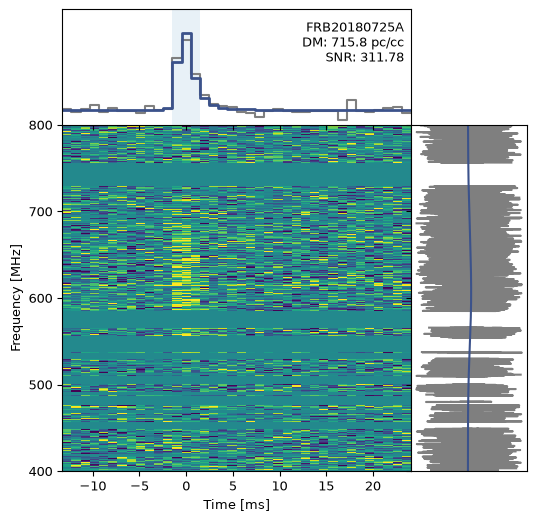

In [14]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(6,6))
## Set up the image grid
gs = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, width_ratios=[3, 1],
                        height_ratios=[1, 3], hspace=0.0, wspace=0.0)
data_im = plt.subplot(gs[2])
data_ts = plt.subplot(gs[0], sharex=data_im)
data_spec = plt.subplot(gs[3], sharey=data_im)


### time stamps relative to the peak
peak_idx = np.argmax(ts)
extent[0] = extent[0] - plot_time[peak_idx]
extent[1] = extent[1] - plot_time[peak_idx]
plot_time -= plot_time[peak_idx]

# prepare time-series for histogramming
plot_time -= dt / 2.
plot_time = np.append(plot_time, plot_time[-1] + dt)

cmap = plt.cm.viridis

### plot dynamic spectrum
wfall[np.isnan(wfall)] = np.nanmedian(wfall)   # replace nans in the data with the data median
# use standard deviation of residuals to set color scale
vmin = np.nanpercentile(wfall, 1)
vmax = np.nanpercentile(wfall, 99)

data_im.imshow(wfall, aspect="auto", interpolation="none",
                extent=extent, vmin=vmin, vmax=vmax, cmap=cmap)

### plot time-series
data_ts.plot(plot_time, np.append(ts, ts[-1]), color="tab:gray",
                drawstyle="steps-post")

### plot spectrum
data_spec.plot(spec, plot_freq, color="tab:gray")

### plot model time-series and spectrum
if scatterfit:
    data_spec.plot(model_spec, plot_freq, color=cmap(0.25))
    data_ts.plot(plot_time, np.append(model_ts, model_ts[-1]),
                    color=cmap(0.25), drawstyle="steps-post", lw=2)
else:
    data_spec.plot(model_spec, plot_freq, color=cmap(0.5))
    data_ts.plot(plot_time, np.append(model_ts, model_ts[-1]),
                    color=cmap(0.5), drawstyle="steps-post", lw=1)


## BEautify plot
# remove some labels and ticks for neatness
plt.setp(data_ts.get_xticklabels(), visible=False)
data_ts.set_yticklabels([], visible=True)
data_ts.set_yticks([])
data_ts.set_xlim(extent[0], extent[1])
plt.setp(data_spec.get_yticklabels(), visible=False)
data_spec.set_xticklabels([], visible=True)
data_spec.set_xticks([])
data_spec.set_ylim(extent[2], extent[3])
plt.setp(data_im.get_xticklabels(), fontsize=9)
plt.setp(data_im.get_yticklabels(), fontsize=9)


#### highlighting the width of the pulse
data_ts.axvspan(max(plot_time.min(),
                        plot_time[peak] + 0.5 * dt \
                        - (0.5 * width) * dt),
                    min(plot_time.max(),
                        plot_time[peak] + 0.5 * dt \
                        + (0.5 * width) * dt),
                    facecolor="tab:blue", edgecolor=None, alpha=0.1)


##### add event ID and DM labels
xlim = data_ts.get_xlim()
ylim = data_ts.get_ylim()

# add 20% extra white space at the top
span = np.abs(ylim[1]) + np.abs(ylim[0])
data_ts.set_ylim(ylim[0], ylim[1] + 0.2 * span)
ylim = data_ts.get_ylim()

ypos = (ylim[1] - ylim[0]) * 0.9 + ylim[0]
xpos = (xlim[1] - xlim[0]) * 0.98 + extent[0]
data_ts.text(xpos, ypos, "{}\nDM: {:.1f} pc/cc\nSNR: {:.2f}".format(eventname, dm,snr), ha="right",
                va="top", fontsize=9)

data_im.locator_params(axis="x", min_n_ticks=3)
data_im.set_yticks([400, 500, 600, 700, 800])
data_im.set_ylabel("Frequency [MHz]", fontsize=9)
data_im.set_xlabel("Time [ms]", fontsize=9)

In [15]:
with h5py.File(path, 'r') as data:
    frb_group = data['frb']
    
    # This prints all attribute keys attached specifically to the 'frb' group
    print("Attributes available in 'frb' group:")
    print(list(frb_group.attrs.keys()))
    
    # Now you can check for your specific attribute
    if 'tns_name' in frb_group.attrs:
        print(f"Found it! Value: {frb_group.attrs['tns_name']}")
    else:
        print("tns_name is not in the 'frb' group.")
    

Attributes available in 'frb' group:
['calibration_observation_date', 'calibration_source_name', 'dm', 'scatterfit', 'tns_name']
Found it! Value: b'FRB20190701D'


### plotting the calibrated data 

In [16]:
cal_ts = np.nanmean(cal_wfall, axis = 0)

Text(0, 0.5, 'Flux [Jy]')

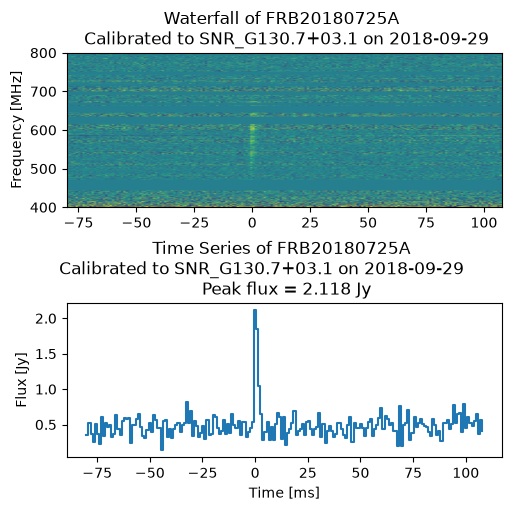

In [17]:
cal_wfall[np.isnan(cal_wfall)] = np.nanmedian(cal_wfall)   # replace nans in the data with the data median
#bin frequency channels such that we have 16,384/16 = 1024 frequency channels 
cal_wfall = bin_freq_channels(cal_wfall,16) 
vmin = np.nanpercentile(cal_wfall, 1)
vmax = np.nanpercentile(cal_wfall, 99)

times = np.arange(len(cal_ts))*dt
peak_idx = np.argmax(cal_ts)
times -= times[peak_idx]
times -= dt / 2.

extent[0] = times[0]
extent[1] = times[-1]

fig = plt.figure(figsize=(5,5), constrained_layout=True)
layout = """
A
C
"""
ax_dict = fig.subplot_mosaic(layout)
ax_dict["A"].imshow(cal_wfall, aspect="auto", vmin=vmin,vmax=vmax, extent = extent )
ax_dict["A"].set_title(f"Waterfall of {eventname} \n Calibrated to {cal_source_name} on {cal_obs_date}")
ax_dict["A"].set_yticks([400, 500, 600, 700, 800])
ax_dict["C"].plot(times,cal_ts, drawstyle="steps-post")
ax_dict["C"].set_xlabel("Time [ms]")
ax_dict["C"].set_title(f"Time Series of {eventname} \nCalibrated to {cal_source_name} on {cal_obs_date} \
        \n Peak flux = {cal_ts[peak_idx]:.3f} Jy")
ax_dict["A"].set_ylabel("Frequency [MHz]")
ax_dict["C"].set_ylabel("Flux [Jy]")

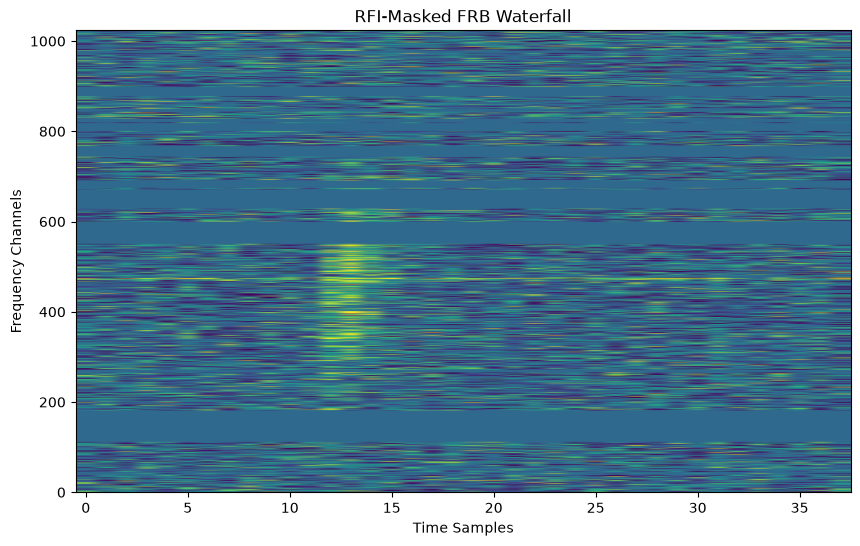

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Use percentiles to set vmin/vmax to ignore remaining noise spikes
vmax = np.nanpercentile(wfall, 99.5)
vmin = np.nanpercentile(wfall, 5)

plt.figure(figsize=(10, 6))
# 'extent' helps map your axes to physical time and frequency values
plt.imshow(wfall, aspect='auto', origin='lower', 
           cmap='viridis', vmin=vmin, vmax=vmax)

#plt.colorbar(label='Intensity')
plt.title("RFI-Masked FRB Waterfall")
plt.xlabel("Time Samples")
plt.ylabel("Frequency Channels")
plt.show()

Here is a line-by-line breakdown of how the code actually loads, filters, and analyzes your FRB waterfall image array.

## Step 1: Loading Your Image Data Array

# 1. Define your exact image file path hereimage_path = "path/to/your/RFI-Masked_FRB_Waterfall.jpg" 


* What it does: This tells Python exactly where to look for your saved waterfall plot file on your computer.

img_array = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)


* What it does: This uses OpenCV to load your image from that path.
* Why it matters: The cv2.IMREAD_GRAYSCALE argument forces OpenCV to ignore color variations and read the file purely as a 2D numerical data matrix (rows of frequency channels and columns of time samples). High-intensity pixels (like the bright yellow FRB) become high numbers, and dark pixels become low numbers.


## Step 2: Isolating the True Noise (The Core Data Logic)

active_pixels = img_array[img_array > 5]


* What it does: This creates a new, filtered array that completely throws away any pixel with a value of 5 or less.
* Why it matters: Your waterfall plot contains giant, dead horizontal bands where Radio Frequency Interference (RFI) was masked out to a flat baseline. If we included those flat, artificial zeros in our calculations, the math would falsely report that your telescope background noise is much quieter than it actually is. This line ensures we only analyze channels that contain actual data.

## Step 3: Calculating the Sigma-Cutoff

noise_mean = np.mean(active_pixels)noise_std = np.std(active_pixels)


* What it does: NumPy (np) computes the baseline mathematical parameters of your background noise.
* np.mean: Finds the average intensity value of the steady telescope thermal noise.
* np.std: Finds the Standard Deviation ($\sigma$), which tells us how wildly the background noise naturally spikes up and down due to standard fluctuations.

cutoff_3sigma = noise_mean + (3 * noise_std)cutoff_5sigma = noise_mean + (5 * noise_std)


* What it does: This sets your definitive astronomical denoising thresholds.
* Why it matters: Statistically, $99.73\%$ of all random background noise spikes will fall below the 3-Sigma line. Over $99.99\%$ will fall below the 5-Sigma line. Any pixel data point bursting above these limits is guaranteed to be your actual scientific FRB signal.


## Step 4: Visualizing the Subplots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


* What it does: This uses Matplotlib (plt) to create a single window (fig) split into a 1-row, 2-column grid of subplots (axes[0] and axes[1]).

axes[0].imshow(img_array, aspect='auto', cmap='viridis', origin='lower')


* What it does: Renders your loaded 2D waterfall data matrix on the left side using the standard astronomy viridis colormap.

counts, bins, patches = axes[1].hist(active_pixels, bins=100, density=True)


* What it does: Generates the Intensity Histogram on the right side. It counts how many pixels fall into different intensity ranges (bins) and plots it as a bar chart distribution.

axes[1].axvline(noise_mean, color='black', linestyle='--')
axes[1].axvline(cutoff_3sigma, color='orange', linestyle='-')
axes[1].axvline(cutoff_5sigma, color='red', linestyle='-')


* What it does: Draws a dashed black vertical line exactly at the average noise level, an orange line at the 3-Sigma limit, and a red line at the 5-Sigma limit right over your bar chart. This shows you exactly where the random noise stops and your real FRB data begins.


To proceed, would you like to see how to use these calculated thresholds to zero out the noise in the array and save the cleaned image? Let me know if you would also like to calculate the Signal-to-Noise Ratio (SNR) of the burst.



#### we are supposed to use the unprocessed data probaly after the RFI noise is not removed . ( rae templates. )
thses sections heere has used the processsed ( prefiltered data)

File not found at '/mnt/d/GCS(trial)/data/chime-frb-open-data-master/output/frb1st.png'. Creating a temporary sample image to keep the code running...
=== CALCULATED MATRIX METRICS ===
Array Intensity Mean       : 105.78
Standard Deviation (Sigma) : 24.25
Recommended 3-Sigma Cutoff : 178.54
Recommended 5-Sigma Cutoff : 227.05


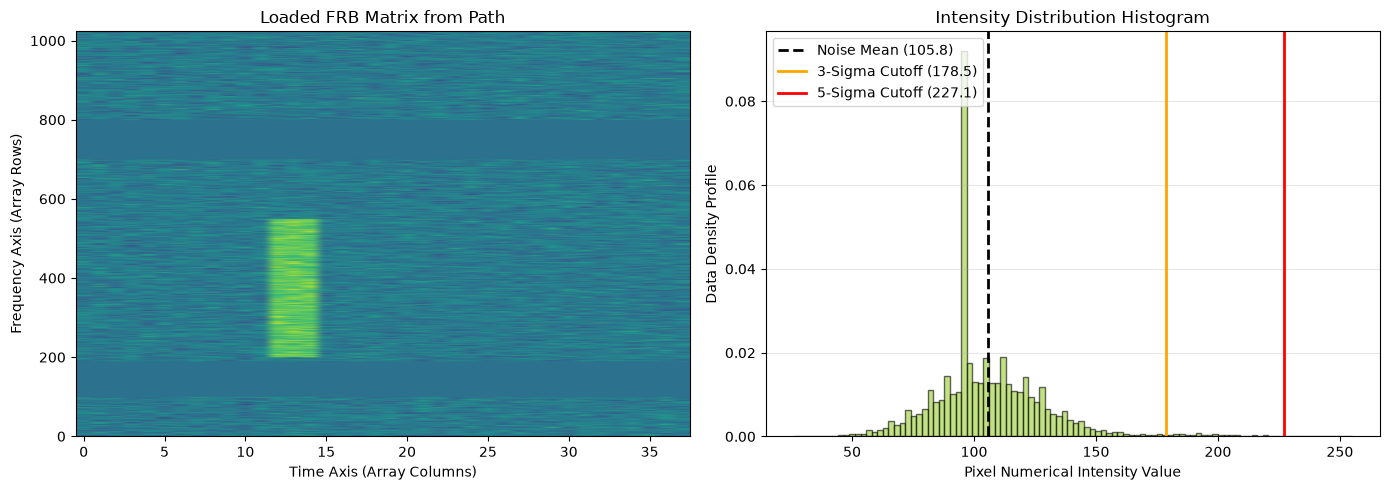

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


image_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/output/frb1st.png"

# Fallback mechanism in case the file path isn't configured yet
if not os.path.exists(image_path):
    print(f"File not found at '{image_path}'. Creating a temporary sample image to keep the code running...")
    # Generate a fake 2D matrix structure mimicking yours
    sample_data = np.random.normal(0.01, 0.02, (1024, 38))
    sample_data[200:550, 12:15] += 0.08  # The burst signal
    sample_data[100:190, :] = 0.0        # Flat RFI mask bands
    sample_data[700:800, :] = 0.0
    # Normalize to 0-255 uint8 range for image processing
    img_array = np.clip((sample_data - sample_data.min()) / (sample_data.max() - sample_data.min()) * 255, 0, 255).astype(np.uint8)
else:
    # Load your actual saved image file in grayscale to read it as a 2D matrix
    img_array = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 2. Extract background noise statistics (Ignoring masked flat zero zones)
# We find where RFI masks are applied by excluding very low pixel values
active_pixels = img_array[img_array > 5]  # Filter out baseline/black padding 

noise_mean = np.mean(active_pixels)
noise_std = np.std(active_pixels)

# Compute astronomical standard thresholds (Sigma-Clipping)
cutoff_3sigma = noise_mean + (3 * noise_std)
cutoff_5sigma = noise_mean + (5 * noise_std)

print("=== CALCULATED MATRIX METRICS ===")
print(f"Array Intensity Mean       : {noise_mean:.2f}")
print(f"Standard Deviation (Sigma) : {noise_std:.2f}")
print(f"Recommended 3-Sigma Cutoff : {cutoff_3sigma:.2f}")
print(f"Recommended 5-Sigma Cutoff : {cutoff_5sigma:.2f}")

# 3. Plot the Subplots: The loaded Image vs Its Array Intensity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Render the loaded data image matrix
axes[0].imshow(img_array, aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title("Loaded FRB Matrix from Path")
axes[0].set_ylabel("Frequency Axis (Array Rows)")
axes[0].set_xlabel("Time Axis (Array Columns)")

# Subplot 2: The Intensity Distribution Histogram
counts, bins, patches = axes[1].hist(active_pixels, bins=100, density=True, 
                                     alpha=0.6, color='yellowgreen', edgecolor='black')

# Draw calculated cutoff thresholds directly on the plot
axes[1].axvline(noise_mean, color='black', linestyle='--', linewidth=2, label=f'Noise Mean ({noise_mean:.1f})')
axes[1].axvline(cutoff_3sigma, color='orange', linestyle='-', linewidth=2, label=f'3-Sigma Cutoff ({cutoff_3sigma:.1f})')
axes[1].axvline(cutoff_5sigma, color='red', linestyle='-', linewidth=2, label=f'5-Sigma Cutoff ({cutoff_5sigma:.1f})')

axes[1].set_title("Intensity Distribution Histogram")
axes[1].set_xlabel("Pixel Numerical Intensity Value")
axes[1].set_ylabel("Data Density Profile")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
